In [62]:
#import
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader
from tarnet import Tarnet
import sys
from pathlib import Path
project_root = Path("/home/ducvu0904/Documents/Lab/RERUM")
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))
sys.path.append("..")
from utils import seed_everything
from metrics import auuc, auqc, lift, krcc

In [63]:
%time train_df = pd.read_csv(r"../dataset/Hillstrom/Men/train_men.csv")
%time test_df =  pd.read_csv(r"../dataset/Hillstrom/Men/test_men.csv")
%time val_df = pd.read_csv(r"../dataset/Hillstrom/Men/val_men.csv")

CPU times: user 10.2 ms, sys: 4.04 ms, total: 14.3 ms
Wall time: 13.8 ms
CPU times: user 5.39 ms, sys: 0 ns, total: 5.39 ms
Wall time: 5.3 ms
CPU times: user 2.05 ms, sys: 0 ns, total: 2.05 ms
Wall time: 2.05 ms


In [64]:
print(train_df[0:4])

    recency  history_segment   history  mens  womens  zip_code  newbie  \
0 -0.214351                4  6.242321     1       0         2       1   
1 -1.356144                4  6.309082     1       0         2       1   
2  1.212890                2  5.817766     1       0         2       1   
3  1.212890                2  5.578408     1       1         1       0   

   channel  treatment  spend  conversion  visit  
0        0          1    0.0           0      1  
1        0          1    0.0           0      0  
2        0          0    0.0           0      0  
3        0          0    0.0           0      0  


In [65]:
in_features = ['recency', 'history_segment', 'history', 'mens', 'womens',
       'zip_code', 'newbie', "channel"]
label_feature = ['spend']
treatment_feature = ['treatment']

In [66]:
# 1. Định nghĩa danh sách các cột (Bạn hãy điều chỉnh tên cột đúng với dữ liệu của mình)
cat_features = ['zip_code', 'channel','history_segment', 'mens', 'womens', 'newbie'] # Các biến phân loại (đã LabelEncode)
num_features = ['recency', 'history']     # Các biến số thực (đã Scale)

def prepare_tensors(df):
    """Hàm hỗ trợ chuyển đổi DataFrame thành các Tensor riêng biệt"""
    # Tách dữ liệu
    X_cat = torch.LongTensor(df[cat_features].values)    # Kiểu Long cho Embedding 
    X_num = torch.FloatTensor(df[num_features].values)  # Kiểu Float cho Projection 
    
    # Biến mục tiêu
    t = torch.FloatTensor(df['treatment'].values).unsqueeze(1)
    y = torch.FloatTensor(df['spend'].values).unsqueeze(1) # Lưu ý: Nên là log(1+y) [cite: 191]
    
    return X_cat, X_num, t, y

# 2. Chuyển đổi cho cả 3 tập dữ liệu [cite: 390]
train_cat, train_num, t_train, y_train = prepare_tensors(train_df)
val_cat, val_num, t_val, y_val = prepare_tensors(val_df)
test_cat, test_num, t_test, y_test = prepare_tensors(test_df)

# 3. Khởi tạo TensorDataset với cấu trúc 4 tham số
train_dataset = TensorDataset(train_cat, train_num, t_train, y_train)
val_dataset = TensorDataset(val_cat, val_num, t_val, y_val)
test_dataset = TensorDataset(test_cat, test_num, t_test, y_test)

# 4. Khởi tạo DataLoader [cite: 398, 419]
# Với 5060Ti, batch_size=1024 hoặc 2048 là tối ưu để gradient không quá phẳng
batch_size = 1024 

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# 5. Thông tin để khởi tạo Model
cat_dims = [train_df[col].nunique() for col in cat_features]
num_count = len(num_features)

print(f"Mô hình sẽ có {len(cat_dims)} lớp Embedding và {num_count} lớp Projection.")

Mô hình sẽ có 6 lớp Embedding và 2 lớp Projection.


In [67]:
epochs = 150
ema = True
patience = 20
print (f" epochs = {epochs}")
print (f" use ema = {ema}")
print (f" patience = {patience}")


 epochs = 150
 use ema = True
 patience = 20


🔃🔃🔃Begin training Tarnet🔃🔃🔃
📊 Early Stop Metric: LOSS
📊 Early Stop Start Epoch: 1
📊 Strategy: Train for 150 epochs, select model with lowest validation loss
   Patience: 20 epochs
Epoch 1/150 | Base Loss: 549.3378 | Uplift Loss: 9.252621 | Total Loss: 558.5904 | Val Loss: 420.9856 | Val Qini: 0.5905 ⭐ NEW BEST (lowest loss) | LR: 0.0001
Epoch 2/150 | Base Loss: 137.9328 | Uplift Loss: -0.836407 | Total Loss: 137.0964 | Val Loss: 420.3143 | Val Qini: 0.7577 ⭐ NEW BEST (lowest loss) | LR: 0.0001
Epoch 3/150 | Base Loss: 165.1935 | Uplift Loss: 8.098348 | Total Loss: 173.2919 | Val Loss: 419.3828 | Val Qini: 0.7672 ⭐ NEW BEST (lowest loss) | LR: 0.0001
Epoch 4/150 | Base Loss: 196.8428 | Uplift Loss: 9.156404 | Total Loss: 205.9992 | Val Loss: 419.1942 | Val Qini: 0.7825 ⭐ NEW BEST (lowest loss) | LR: 0.0001
Epoch 5/150 | Base Loss: 101.9856 | Uplift Loss: 5.298761 | Total Loss: 107.2844 | Val Loss: 419.1534 | Val Qini: 0.7809 ⭐ NEW BEST (lowest loss) | LR: 0.0001
Epoch 6/150 | Base Loss:

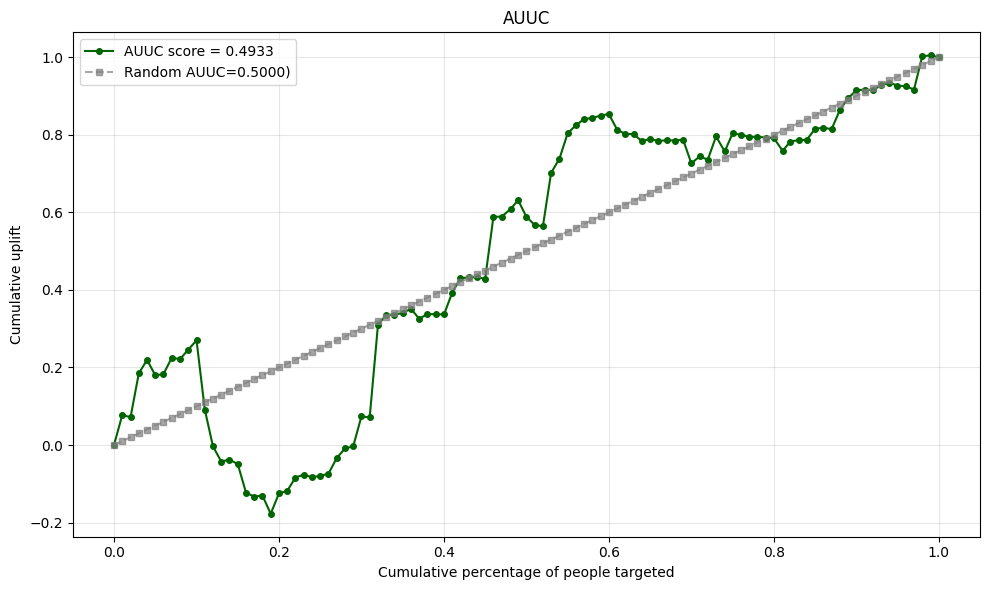

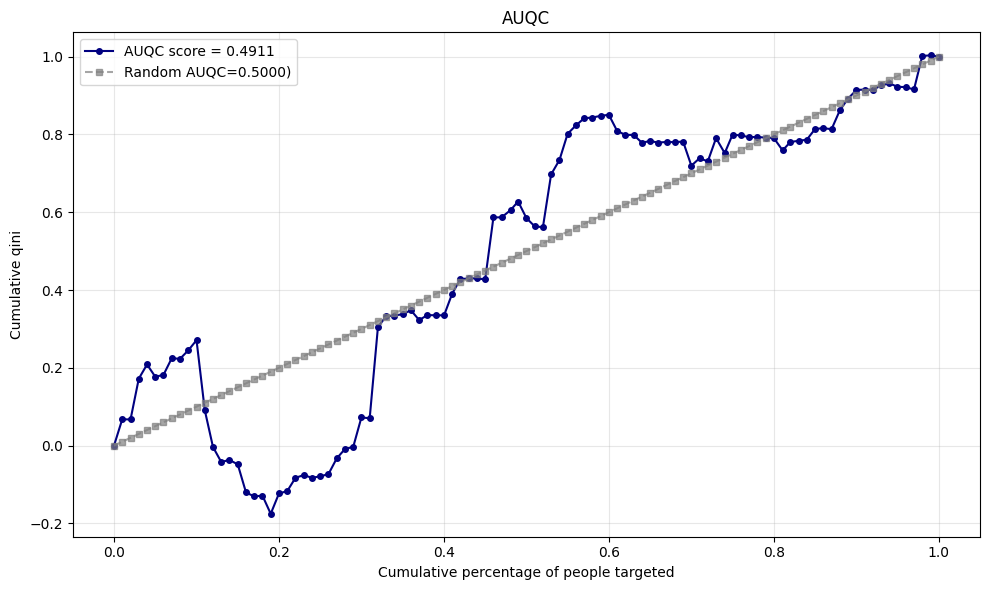

Done Seed 412312
🔃🔃🔃Begin training Tarnet🔃🔃🔃
📊 Early Stop Metric: LOSS
📊 Early Stop Start Epoch: 1
📊 Strategy: Train for 150 epochs, select model with lowest validation loss
   Patience: 20 epochs
Epoch 1/150 | Base Loss: 32.9597 | Uplift Loss: 0.224283 | Total Loss: 33.1839 | Val Loss: 420.5359 | Val Qini: 0.7148 ⭐ NEW BEST (lowest loss) | LR: 0.0001
Epoch 2/150 | Base Loss: 122.9821 | Uplift Loss: 5.457573 | Total Loss: 128.4397 | Val Loss: 419.7595 | Val Qini: 0.7905 ⭐ NEW BEST (lowest loss) | LR: 0.0001
Epoch 3/150 | Base Loss: 70.2223 | Uplift Loss: 1.651266 | Total Loss: 71.8736 | Val Loss: 419.1332 | Val Qini: 0.8261 ⭐ NEW BEST (lowest loss) | LR: 0.0001
Epoch 4/150 | Base Loss: 147.5788 | Uplift Loss: -4.383879 | Total Loss: 143.1949 | Val Loss: 419.0352 | Val Qini: 0.8291 ⭐ NEW BEST (lowest loss) | LR: 0.0001
Epoch 5/150 | Base Loss: 67.8887 | Uplift Loss: 2.052924 | Total Loss: 69.9417 | Val Loss: 419.0085 | Val Qini: 0.8336 ⭐ NEW BEST (lowest loss) | LR: 0.0001
Epoch 6/150 |

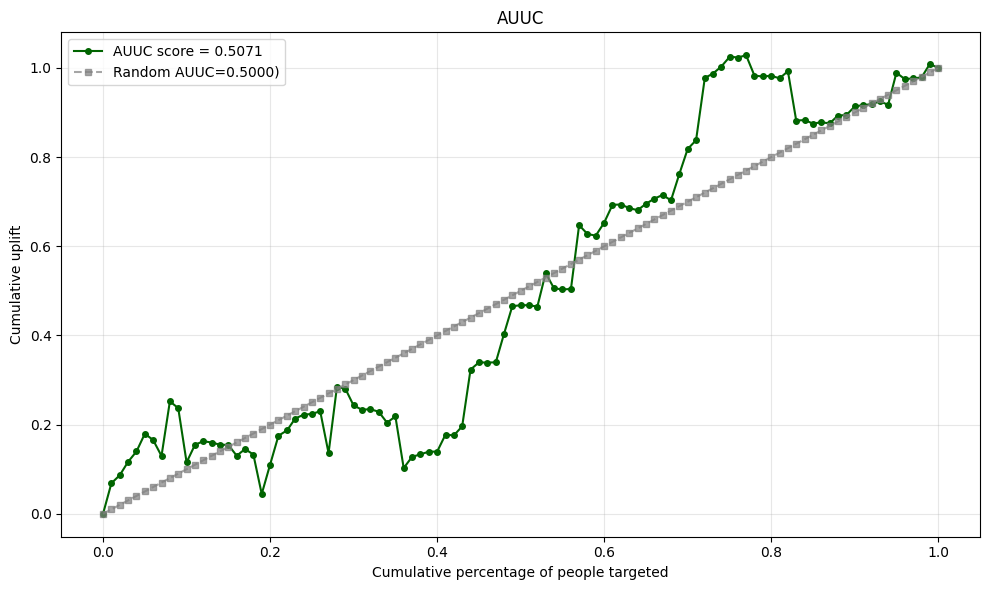

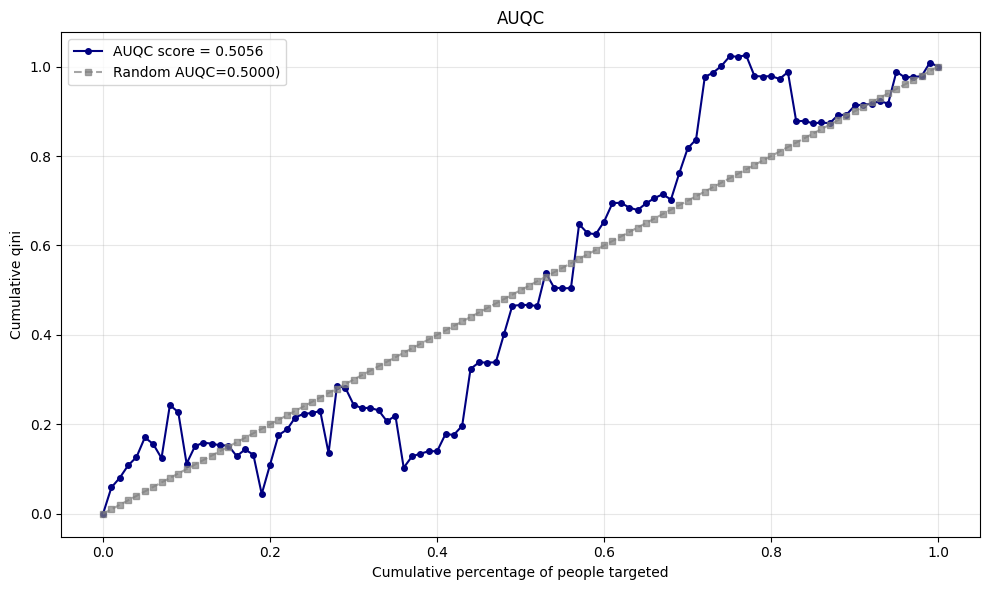

Done Seed 42
🔃🔃🔃Begin training Tarnet🔃🔃🔃
📊 Early Stop Metric: LOSS
📊 Early Stop Start Epoch: 1
📊 Strategy: Train for 150 epochs, select model with lowest validation loss
   Patience: 20 epochs
Epoch 1/150 | Base Loss: 478.5339 | Uplift Loss: -0.952171 | Total Loss: 477.5817 | Val Loss: 420.9018 | Val Qini: 0.7612 ⭐ NEW BEST (lowest loss) | LR: 0.0001
Epoch 2/150 | Base Loss: 14.5986 | Uplift Loss: 1.400329 | Total Loss: 15.9989 | Val Loss: 420.1470 | Val Qini: 0.7749 ⭐ NEW BEST (lowest loss) | LR: 0.0001
Epoch 3/150 | Base Loss: 313.0792 | Uplift Loss: -2.461174 | Total Loss: 310.6180 | Val Loss: 419.0538 | Val Qini: 0.8022 ⭐ NEW BEST (lowest loss) | LR: 0.0001
Epoch 4/150 | Base Loss: 993.6398 | Uplift Loss: 21.058235 | Total Loss: 1014.6980 | Val Loss: 418.9374 | Val Qini: 0.8003 ⭐ NEW BEST (lowest loss) | LR: 0.0001
Epoch 5/150 | Base Loss: 303.8242 | Uplift Loss: 2.980911 | Total Loss: 306.8051 | Val Loss: 418.9229 | Val Qini: 0.7819 ⭐ NEW BEST (lowest loss) | LR: 0.0001
Epoch 6/15

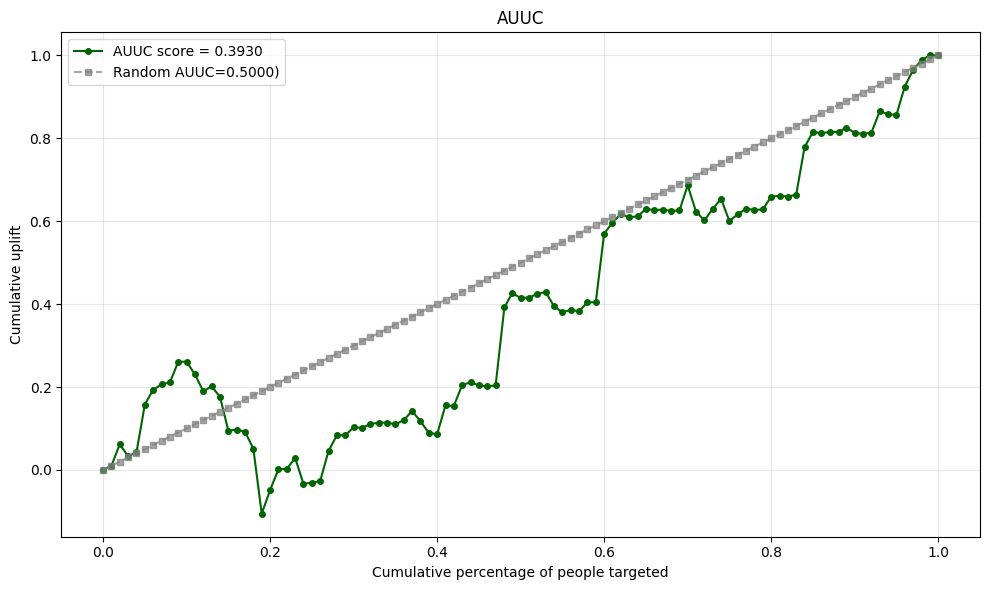

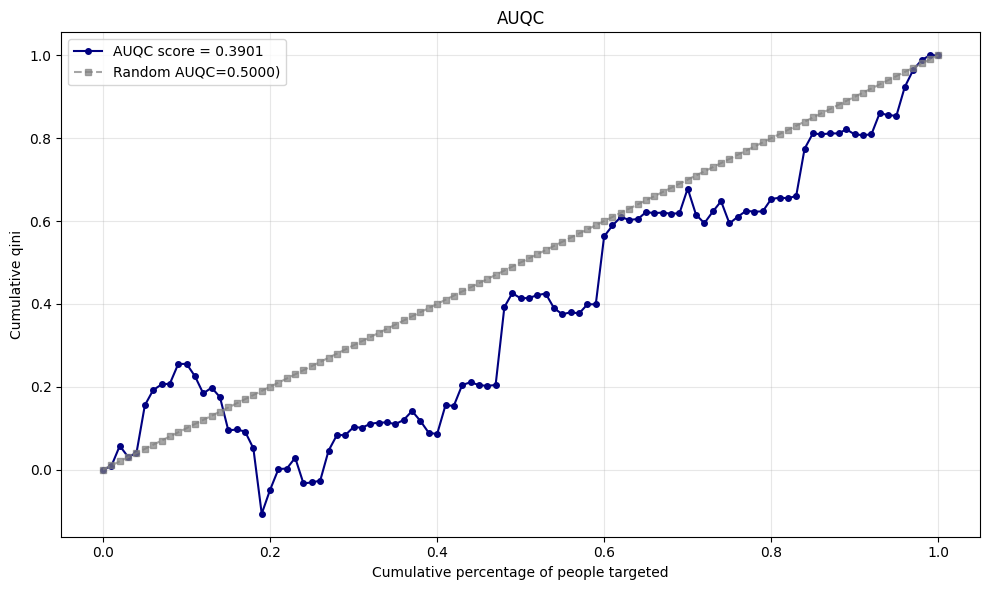

Done Seed 1874
🔃🔃🔃Begin training Tarnet🔃🔃🔃
📊 Early Stop Metric: LOSS
📊 Early Stop Start Epoch: 1
📊 Strategy: Train for 150 epochs, select model with lowest validation loss
   Patience: 20 epochs
Epoch 1/150 | Base Loss: 151.7831 | Uplift Loss: 0.206415 | Total Loss: 151.9895 | Val Loss: 420.7841 | Val Qini: 0.7459 ⭐ NEW BEST (lowest loss) | LR: 0.0001
Epoch 2/150 | Base Loss: 191.3943 | Uplift Loss: -2.830767 | Total Loss: 188.5635 | Val Loss: 419.9132 | Val Qini: 0.7788 ⭐ NEW BEST (lowest loss) | LR: 0.0001
Epoch 3/150 | Base Loss: 934.2057 | Uplift Loss: 10.576586 | Total Loss: 944.7823 | Val Loss: 419.2610 | Val Qini: 0.7510 ⭐ NEW BEST (lowest loss) | LR: 0.0001
Epoch 4/150 | Base Loss: 772.5383 | Uplift Loss: 5.696906 | Total Loss: 778.2352 | Val Loss: 419.1889 | Val Qini: 0.7607 ⭐ NEW BEST (lowest loss) | LR: 0.0001
Epoch 5/150 | Base Loss: 298.7366 | Uplift Loss: 4.914148 | Total Loss: 303.6507 | Val Loss: 419.1767 | Val Qini: 0.7456 ⭐ NEW BEST (lowest loss) | LR: 0.0001
Epoch 6/

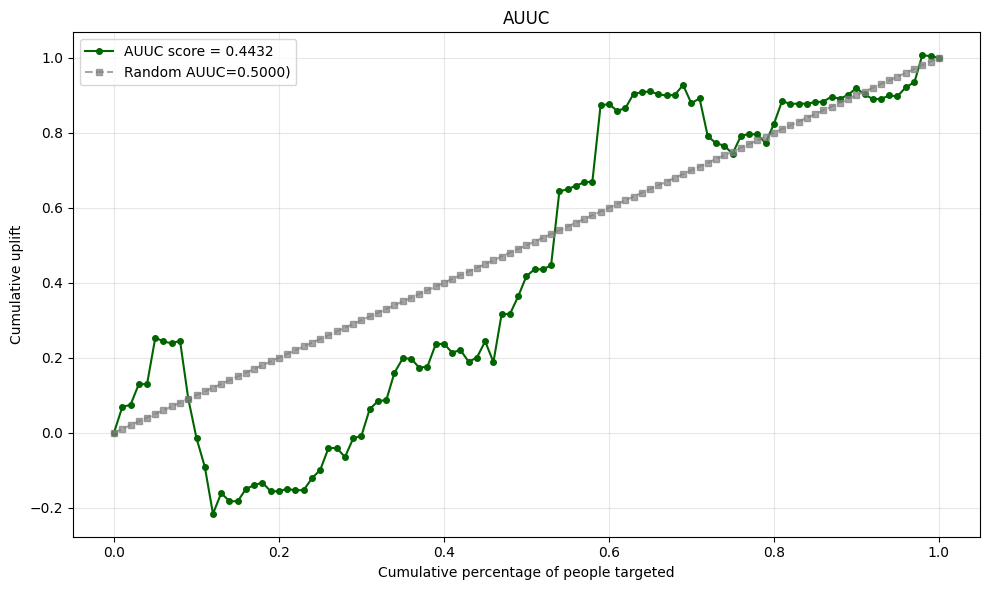

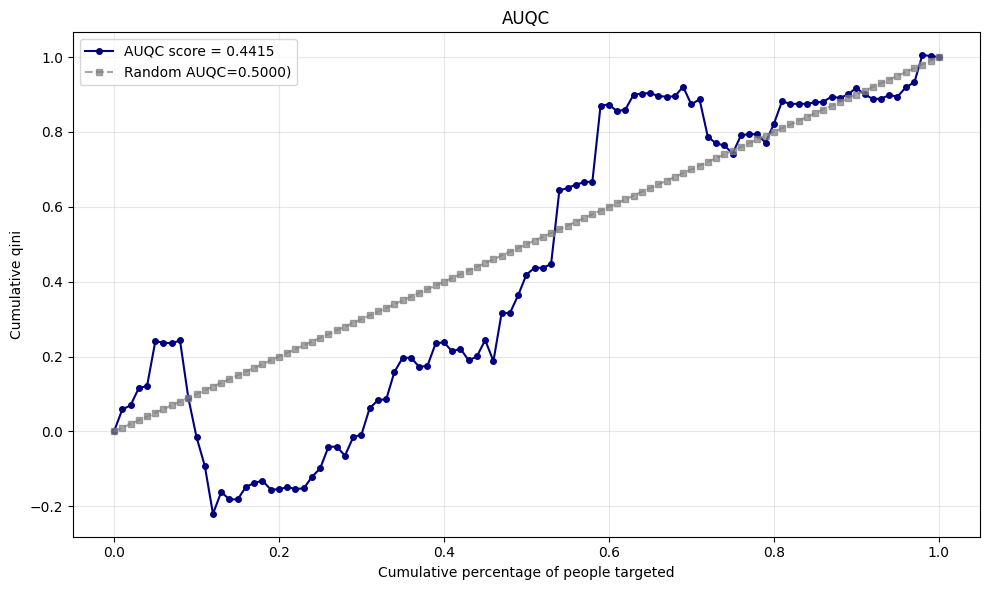

Done Seed 902745
🔃🔃🔃Begin training Tarnet🔃🔃🔃
📊 Early Stop Metric: LOSS
📊 Early Stop Start Epoch: 1
📊 Strategy: Train for 150 epochs, select model with lowest validation loss
   Patience: 20 epochs
Epoch 1/150 | Base Loss: 289.5283 | Uplift Loss: 5.481509 | Total Loss: 295.0098 | Val Loss: 420.8059 | Val Qini: 0.8435 ⭐ NEW BEST (lowest loss) | LR: 0.0001
Epoch 2/150 | Base Loss: 420.4226 | Uplift Loss: 1.396967 | Total Loss: 421.8196 | Val Loss: 419.7949 | Val Qini: 0.8001 ⭐ NEW BEST (lowest loss) | LR: 0.0001
Epoch 3/150 | Base Loss: 123.5475 | Uplift Loss: 0.304408 | Total Loss: 123.8519 | Val Loss: 419.2019 | Val Qini: 0.8024 ⭐ NEW BEST (lowest loss) | LR: 0.0001
Epoch 4/150 | Base Loss: 30.7006 | Uplift Loss: -0.399586 | Total Loss: 30.3010 | Val Loss: 419.1379 | Val Qini: 0.8100 ⭐ NEW BEST (lowest loss) | LR: 0.0001
Epoch 5/150 | Base Loss: 1112.3345 | Uplift Loss: 22.235874 | Total Loss: 1134.5703 | Val Loss: 419.0974 | Val Qini: 0.8149 ⭐ NEW BEST (lowest loss) | LR: 0.0001
Epoch 

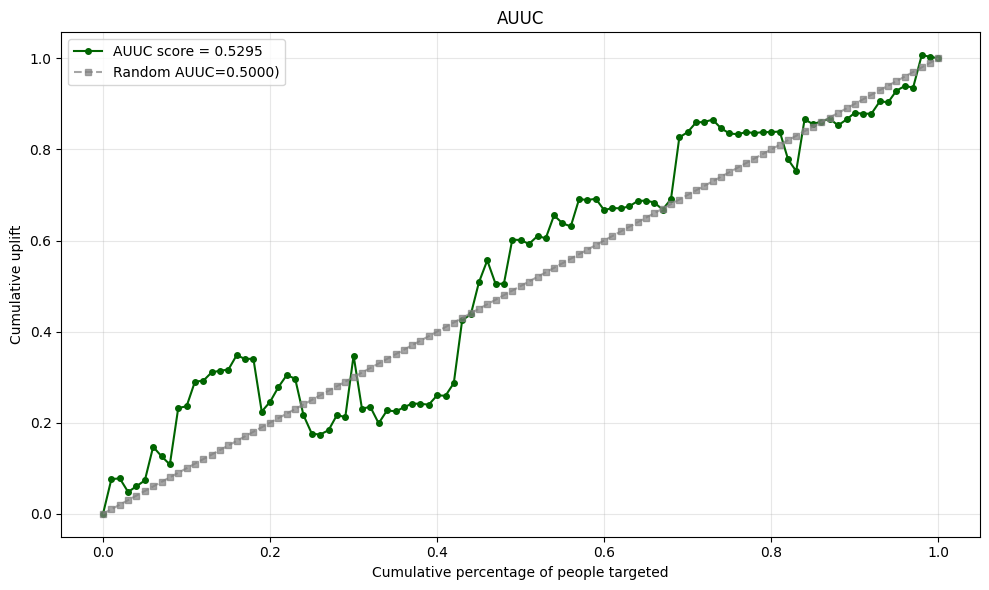

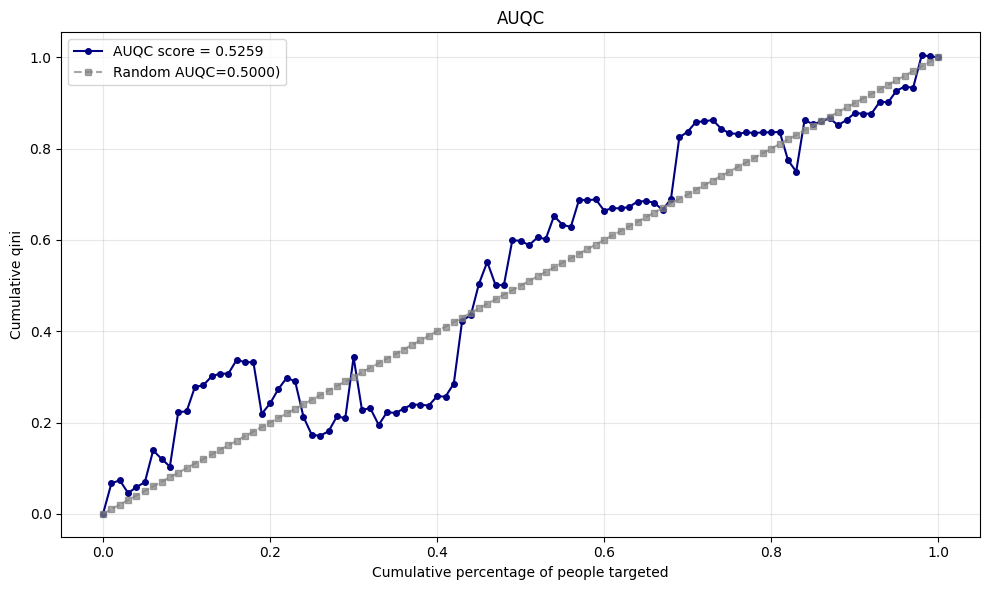

Done Seed 1
🔃🔃🔃Begin training Tarnet🔃🔃🔃
📊 Early Stop Metric: LOSS
📊 Early Stop Start Epoch: 1
📊 Strategy: Train for 150 epochs, select model with lowest validation loss
   Patience: 20 epochs
Epoch 1/150 | Base Loss: 330.7889 | Uplift Loss: 8.302422 | Total Loss: 339.0913 | Val Loss: 420.9450 | Val Qini: 0.7351 ⭐ NEW BEST (lowest loss) | LR: 0.0001
Epoch 2/150 | Base Loss: 582.9530 | Uplift Loss: 0.653543 | Total Loss: 583.6066 | Val Loss: 420.2408 | Val Qini: 0.8927 ⭐ NEW BEST (lowest loss) | LR: 0.0001
Epoch 3/150 | Base Loss: 203.0868 | Uplift Loss: -1.300616 | Total Loss: 201.7862 | Val Loss: 419.2756 | Val Qini: 0.8934 ⭐ NEW BEST (lowest loss) | LR: 0.0001
Epoch 4/150 | Base Loss: 187.2547 | Uplift Loss: 5.886206 | Total Loss: 193.1409 | Val Loss: 418.9390 | Val Qini: 0.8929 ⭐ NEW BEST (lowest loss) | LR: 0.0001
Epoch 5/150 | Base Loss: 1199.8967 | Uplift Loss: -9.290450 | Total Loss: 1190.6063 | Val Loss: 418.8711 | Val Qini: 0.8777 ⭐ NEW BEST (lowest loss) | LR: 0.0001
Epoch 6/1

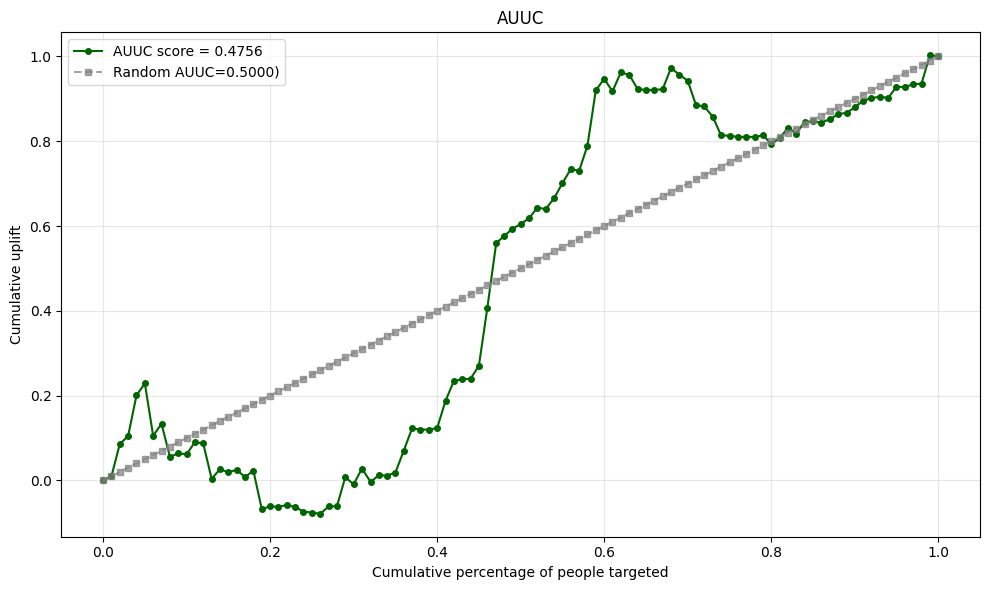

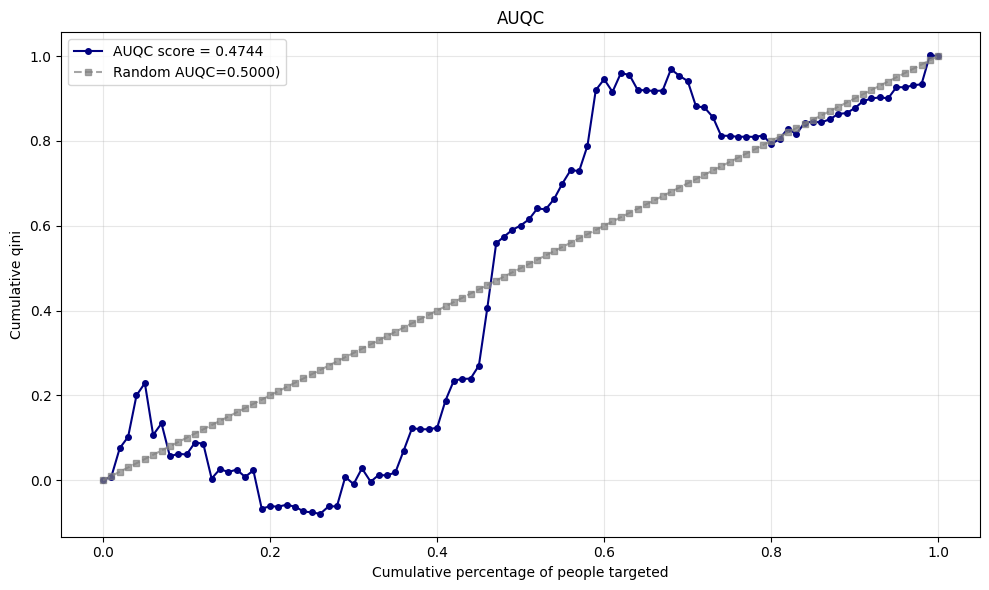

Done Seed 2
🔃🔃🔃Begin training Tarnet🔃🔃🔃
📊 Early Stop Metric: LOSS
📊 Early Stop Start Epoch: 1
📊 Strategy: Train for 150 epochs, select model with lowest validation loss
   Patience: 20 epochs
Epoch 1/150 | Base Loss: 453.5178 | Uplift Loss: 8.360195 | Total Loss: 461.8780 | Val Loss: 421.4149 | Val Qini: 0.8525 ⭐ NEW BEST (lowest loss) | LR: 0.0001
Epoch 2/150 | Base Loss: 391.5190 | Uplift Loss: -3.924145 | Total Loss: 387.5949 | Val Loss: 420.8676 | Val Qini: 0.6414 ⭐ NEW BEST (lowest loss) | LR: 0.0001
Epoch 3/150 | Base Loss: 146.0613 | Uplift Loss: 2.258976 | Total Loss: 148.3203 | Val Loss: 419.6300 | Val Qini: 0.7662 ⭐ NEW BEST (lowest loss) | LR: 0.0001
Epoch 4/150 | Base Loss: 123.4749 | Uplift Loss: -0.940424 | Total Loss: 122.5345 | Val Loss: 419.2798 | Val Qini: 0.7795 ⭐ NEW BEST (lowest loss) | LR: 0.0001
Epoch 5/150 | Base Loss: 209.3625 | Uplift Loss: 5.897419 | Total Loss: 215.2599 | Val Loss: 419.1468 | Val Qini: 0.7700 ⭐ NEW BEST (lowest loss) | LR: 0.0001
Epoch 6/150

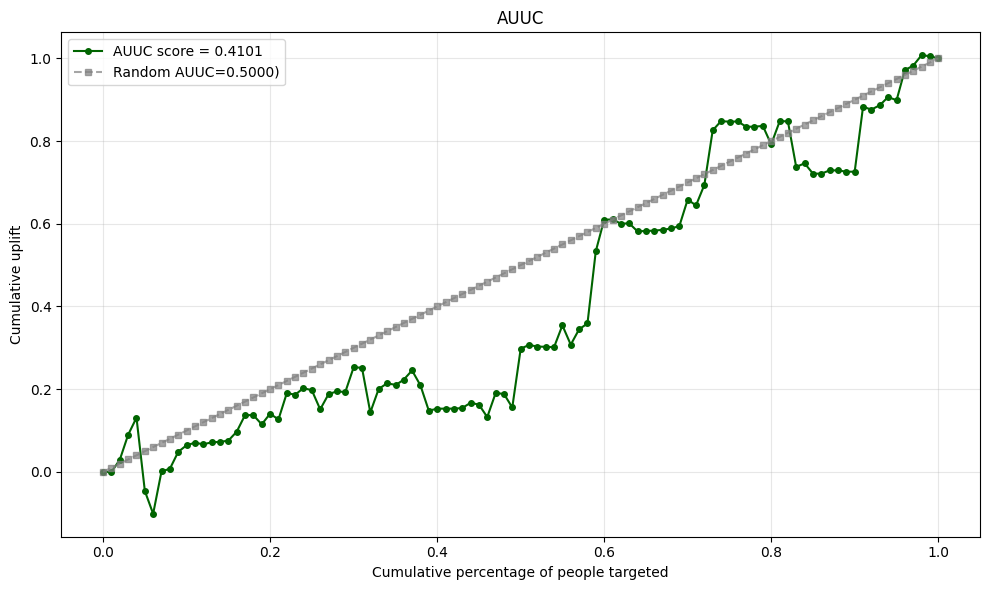

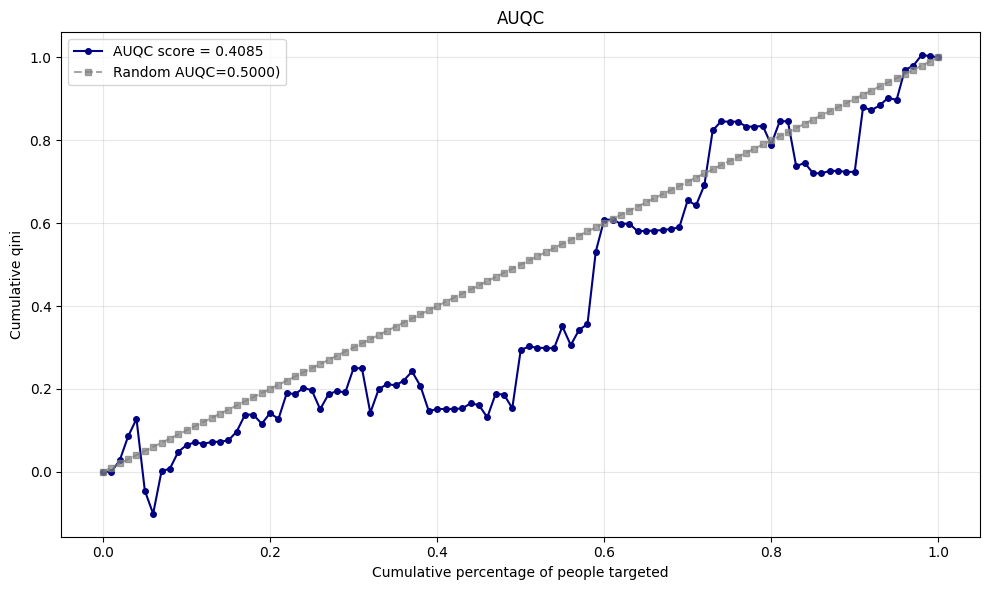

Done Seed 3
🔃🔃🔃Begin training Tarnet🔃🔃🔃
📊 Early Stop Metric: LOSS
📊 Early Stop Start Epoch: 1
📊 Strategy: Train for 150 epochs, select model with lowest validation loss
   Patience: 20 epochs
Epoch 1/150 | Base Loss: 448.1022 | Uplift Loss: 13.922849 | Total Loss: 462.0251 | Val Loss: 421.0829 | Val Qini: 0.4948 ⭐ NEW BEST (lowest loss) | LR: 0.0001
Epoch 2/150 | Base Loss: 101.6741 | Uplift Loss: 1.466572 | Total Loss: 103.1407 | Val Loss: 420.4351 | Val Qini: 0.5449 ⭐ NEW BEST (lowest loss) | LR: 0.0001
Epoch 3/150 | Base Loss: 706.0588 | Uplift Loss: 5.765817 | Total Loss: 711.8246 | Val Loss: 419.5305 | Val Qini: 0.6638 ⭐ NEW BEST (lowest loss) | LR: 0.0001
Epoch 4/150 | Base Loss: 149.4822 | Uplift Loss: 6.241405 | Total Loss: 155.7236 | Val Loss: 419.3172 | Val Qini: 0.7361 ⭐ NEW BEST (lowest loss) | LR: 0.0001
Epoch 5/150 | Base Loss: 1031.5599 | Uplift Loss: 9.142519 | Total Loss: 1040.7025 | Val Loss: 419.2519 | Val Qini: 0.7748 ⭐ NEW BEST (lowest loss) | LR: 0.0001
Epoch 6/15

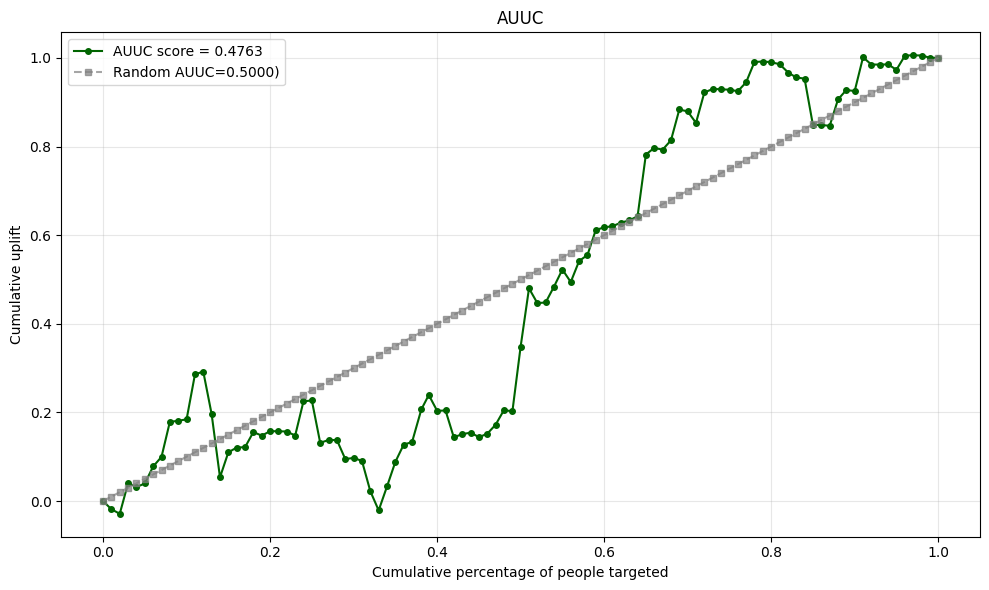

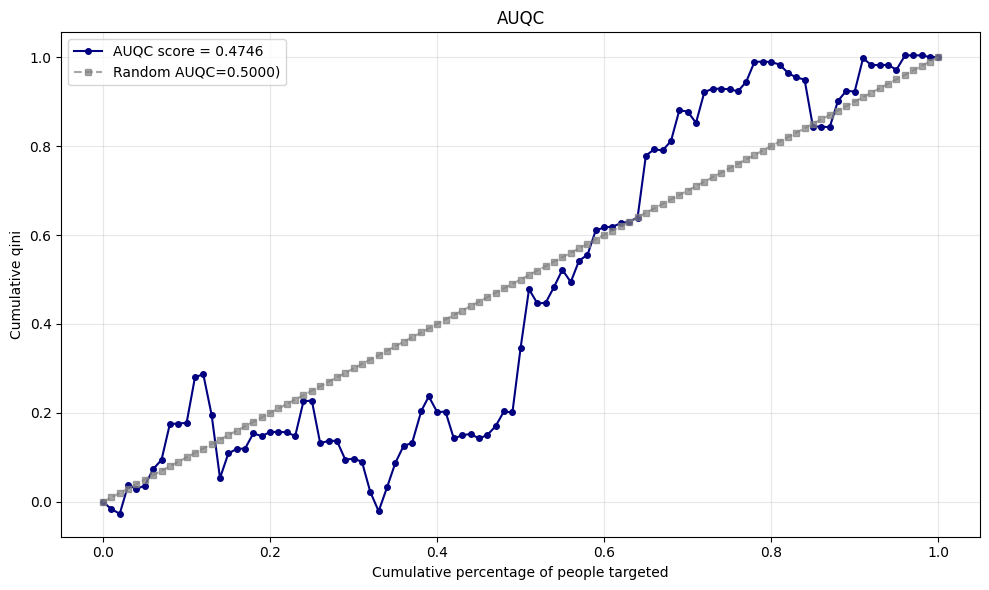

Done Seed 4
🔃🔃🔃Begin training Tarnet🔃🔃🔃
📊 Early Stop Metric: LOSS
📊 Early Stop Start Epoch: 1
📊 Strategy: Train for 150 epochs, select model with lowest validation loss
   Patience: 20 epochs
Epoch 1/150 | Base Loss: 405.9795 | Uplift Loss: 11.350174 | Total Loss: 417.3297 | Val Loss: 420.8307 | Val Qini: 0.7379 ⭐ NEW BEST (lowest loss) | LR: 0.0001
Epoch 2/150 | Base Loss: 1034.3854 | Uplift Loss: 4.556031 | Total Loss: 1038.9414 | Val Loss: 420.2106 | Val Qini: 0.8554 ⭐ NEW BEST (lowest loss) | LR: 0.0001
Epoch 3/150 | Base Loss: 368.7456 | Uplift Loss: 7.726096 | Total Loss: 376.4717 | Val Loss: 419.2237 | Val Qini: 0.8606 ⭐ NEW BEST (lowest loss) | LR: 0.0001
Epoch 4/150 | Base Loss: 409.2020 | Uplift Loss: 6.089540 | Total Loss: 415.2915 | Val Loss: 418.9018 | Val Qini: 0.8728 ⭐ NEW BEST (lowest loss) | LR: 0.0001
Epoch 5/150 | Base Loss: 688.5538 | Uplift Loss: -5.705720 | Total Loss: 682.8481 | Val Loss: 418.8966 | Val Qini: 0.8706 ⭐ NEW BEST (lowest loss) | LR: 0.0001
Epoch 6/1

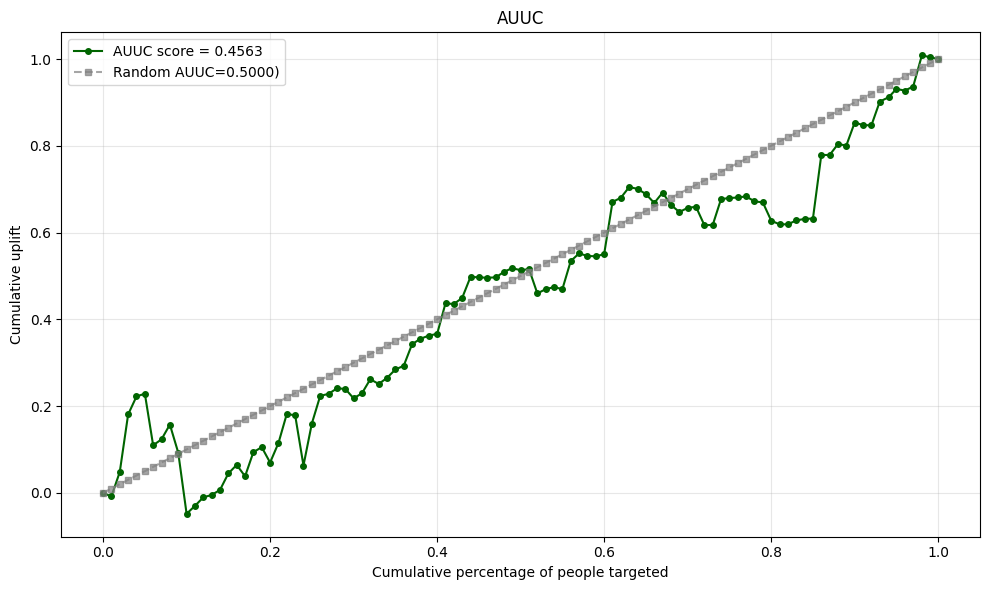

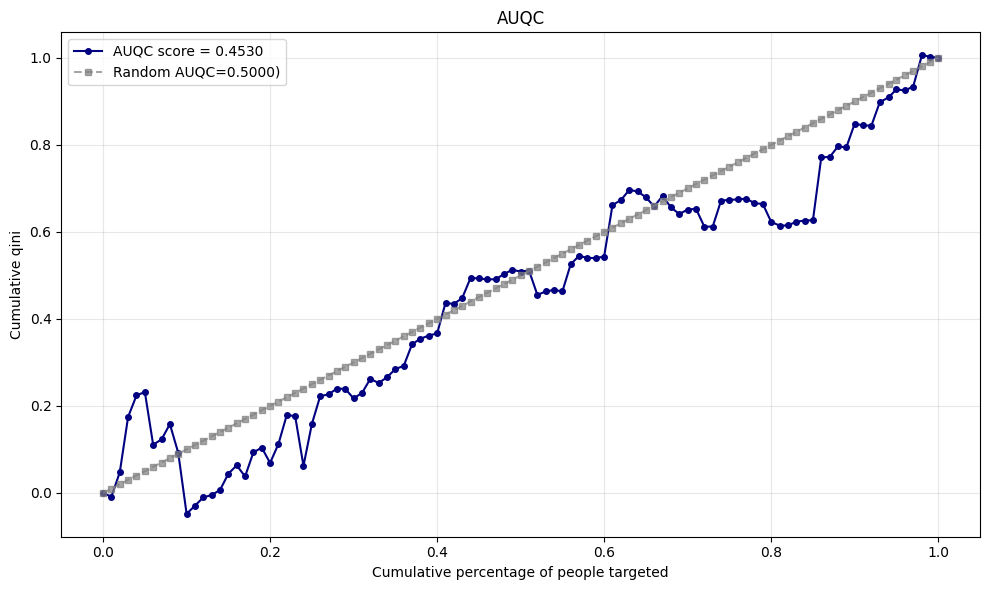

Done Seed 5
🔃🔃🔃Begin training Tarnet🔃🔃🔃
📊 Early Stop Metric: LOSS
📊 Early Stop Start Epoch: 1
📊 Strategy: Train for 150 epochs, select model with lowest validation loss
   Patience: 20 epochs
Epoch 1/150 | Base Loss: 433.5659 | Uplift Loss: 9.484195 | Total Loss: 443.0500 | Val Loss: 421.1986 | Val Qini: 0.6903 ⭐ NEW BEST (lowest loss) | LR: 0.0001
Epoch 2/150 | Base Loss: 353.8875 | Uplift Loss: 8.052936 | Total Loss: 361.9405 | Val Loss: 420.4812 | Val Qini: 0.7391 ⭐ NEW BEST (lowest loss) | LR: 0.0001
Epoch 3/150 | Base Loss: 1332.3125 | Uplift Loss: 16.082005 | Total Loss: 1348.3945 | Val Loss: 419.4180 | Val Qini: 0.6709 ⭐ NEW BEST (lowest loss) | LR: 0.0001
Epoch 4/150 | Base Loss: 76.1331 | Uplift Loss: -4.058012 | Total Loss: 72.0751 | Val Loss: 419.2736 | Val Qini: 0.6591 ⭐ NEW BEST (lowest loss) | LR: 0.0001
Epoch 5/150 | Base Loss: 314.5121 | Uplift Loss: 6.083848 | Total Loss: 320.5960 | Val Loss: 419.2028 | Val Qini: 0.6820 ⭐ NEW BEST (lowest loss) | LR: 0.0001
Epoch 6/150

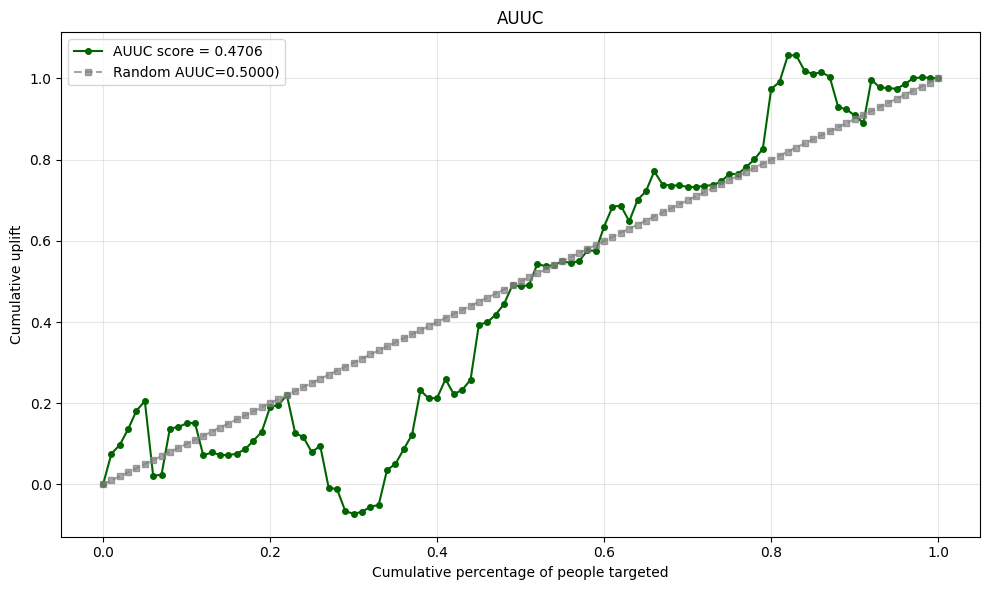

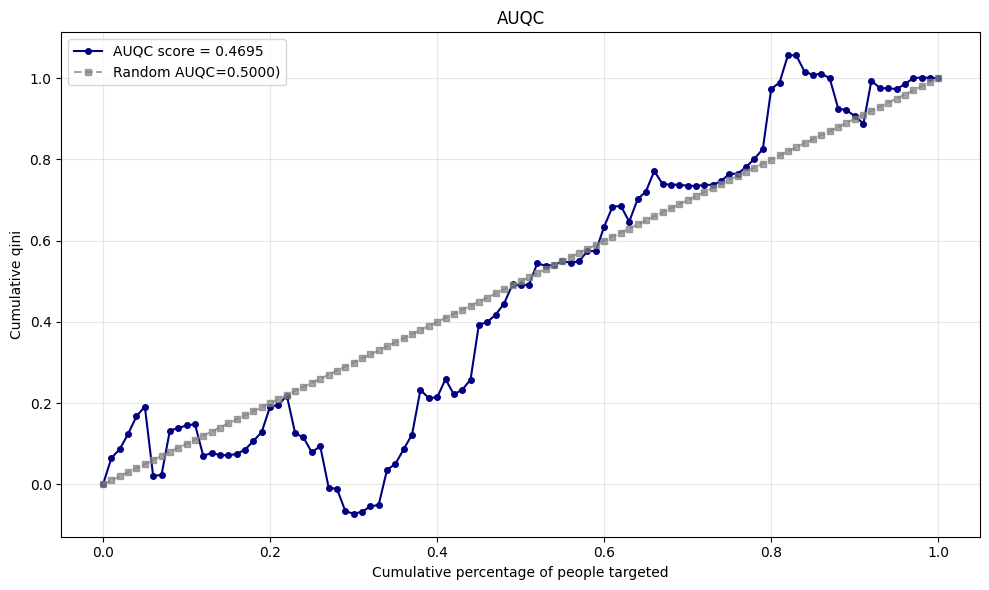

Done Seed 6

                             PER-SEED DETAILS (TEST SET)                             
  Seed   AUUC   AUQC    Lift    KRCC ATE_Err
412312 0.4933 0.4911  0.1452  0.0465  0.1335
    42 0.5071 0.5056  0.4750  0.0393  0.1428
  1874 0.3930 0.3901  0.2004 -0.0565  0.2240
902745 0.4432 0.4415 -0.0158  0.0411  0.1697
     1 0.5295 0.5259  0.6809  0.0537  0.1216
     2 0.4756 0.4744 -0.0188  0.0302  0.3055
     3 0.4101 0.4085  0.4948  0.0289  0.2439
     4 0.4763 0.4746  0.1911  0.0316  0.1999
     5 0.4563 0.4530  0.4257  0.0767  0.2735
     6 0.4706 0.4695 -0.1407  0.0936  0.2008
                              TEST SUMMARY (MEAN ± STD)                              
-------------------------------------------------------------------------------------
AUUC      : 0.4655 ± 0.0418
AUQC      : 0.4634 ± 0.0418
Lift      : 0.2438 ± 0.2665
KRCC      : 0.0385 ± 0.0395
ATE_Err   : 0.2015 ± 0.0613


In [68]:
import pandas as pd
import numpy as np
import torch

# 1. Evaluate selected config on test set (after tuning)
seeds = [412312, 42, 1874, 902745, 1, 2, 3, 4, 5, 6] # Extended to 10 seeds for more robust evaluation
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
all_runs = []

# 2. Loop over seeds for robust test evaluation
for SEED in seeds:
    seed_everything(SEED)

    tarnet = Tarnet(
        cate_dims=cat_dims,
        num_count=num_count,
        epochs=150,
        learning_rate=1e-4,
        weight_decay=1e-5,
        patience=patience,
        shared_hidden=200,
        outcome_hidden=100,
        outcome_dropout=0.0,
        shared_dropout=0.0,
        early_stop_metric="loss",
        early_stop_start_epoch=0,
        uplift_ranking= 1,
        response_ranking=0,
        ranking_start_epoch=0,
        max_samples=10000


    )

    tarnet.fit(train_loader, val_loader)

    # Test prediction
    test_cat_device = test_cat.to(device)
    test_num_device = test_num.to(device)
    y0_pred, y1_pred = tarnet.predict(test_cat_device, test_num_device)

    uplift_pred = (y1_pred - y0_pred).detach().cpu().numpy().flatten()
    y_true = y_test.detach().cpu().numpy().flatten()
    t_true = t_test.detach().cpu().numpy().flatten()

    # ATE error
    ate_pred = uplift_pred.mean()
    ate_true = y_true[t_true == 1].mean() - y_true[t_true == 0].mean()

    all_runs.append({
        'Seed': SEED,
        'AUUC': auuc(y_true, t_true, uplift_pred, bins=100, plot=True),
        'AUQC': auqc(y_true, t_true, uplift_pred, bins=100, plot=True),
        'Lift': lift(y_true, t_true, uplift_pred, h=0.3),
        'KRCC': krcc(y_true, t_true, uplift_pred, bins=100),
        'ATE_Err': abs(ate_pred - ate_true)
    })
    print(f"Done Seed {SEED}")

# 3. Aggregate final test metrics
df_results = pd.DataFrame(all_runs)

print("\n" + "=" * 85)
print(f"{'PER-SEED DETAILS (TEST SET)':^85}")
print("=" * 85)
print(df_results.to_string(index=False, formatters={
    'AUUC': '{:,.4f}'.format,
    'AUQC': '{:,.4f}'.format,
    'Lift': '{:,.4f}'.format,
    'KRCC': '{:,.4f}'.format,
    'ATE_Err': '{:,.4f}'.format
}))

mean_res = df_results.drop(columns='Seed').mean()
std_res = df_results.drop(columns='Seed').std()

print("=" * 85)
print(f"{'TEST SUMMARY (MEAN ± STD)':^85}")
print("-" * 85)
for metric in ['AUUC', 'AUQC', 'Lift', 'KRCC', 'ATE_Err']:
    print(f"{metric:<10}: {mean_res[metric]:.4f} ± {std_res[metric]:.4f}")
print("=" * 85)